# Digital Payments Intelligence Dashboard

## Project Overview

The Digital Payments Intelligence Dashboard is a FinTech analytics project designed to analyze digital payment transactions and generate actionable business insights. The project focuses on understanding transaction behavior, payment method usage, customer activity, merchant interactions, transaction value distribution, and fraud monitoring.

Using Python, the dataset was cleaned, transformed, and enriched through feature engineering to create business-oriented metrics suitable for dashboard reporting and decision-making.

## Objectives

- Analyze digital payment transaction patterns.
- Evaluate payment method adoption and usage.
- Identify customer and merchant transaction behavior.
- Measure transaction success and fraud rates.
- Segment transactions based on value ranges.
- Generate business insights for FinTech platforms.

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- SQL
- Power BI

## Dataset Features

The final dataset includes:

- Step
- Transaction Type
- Transaction Amount
- Customer ID
- Recipient ID
- Fraud Indicator
- Payment Method
- Transaction Status
- Transaction Category
- Amount Segment

In [1]:
pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [10]:
df = pd.read_csv("/content/Digital_payments_Dataset.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [53]:
df.shape

(138115, 13)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 138115 entries, 0 to 138114
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   step                  138115 non-null  int64   
 1   type                  138115 non-null  object  
 2   amount                138115 non-null  float64 
 3   nameOrig              138115 non-null  object  
 4   oldbalanceOrg         138115 non-null  float64 
 5   newbalanceOrig        138115 non-null  float64 
 6   nameDest              138115 non-null  object  
 7   oldbalanceDest        138115 non-null  float64 
 8   newbalanceDest        138115 non-null  float64 
 9   isFraud               138115 non-null  float64 
 10  isFlaggedFraud        138115 non-null  float64 
 11  Transaction_Category  138115 non-null  object  
 12  Amount_Segment        138115 non-null  category
dtypes: category(1), float64(7), int64(1), object(4)
memory usage: 13.8+ MB


In [55]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,138115.000000,1.381150e+05,1.381150e+05,1.381150e+05,1.381150e+05,1.381150e+05,138115.000000,138115.0
mean,9.126539,1.784274e+05,8.958035e+05,9.121331e+05,9.069548e+05,1.183330e+06,0.000883,0.0
std,1.868878,3.417507e+05,2.824677e+06,2.861615e+06,2.386388e+06,2.726211e+06,0.029708,0.0
min,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,8.000000,1.088958e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,9.000000,6.005955e+04,2.003800e+04,0.000000e+00,3.084900e+04,8.544306e+04,0.000000,0.0
75%,10.000000,2.210860e+05,1.963100e+05,2.247541e+05,6.666913e+05,1.114277e+06,0.000000,0.0
max,11.000000,1.000000e+07,3.893942e+07,3.894623e+07,3.490552e+07,3.894623e+07,1.000000,0.0


In [56]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [57]:
df['type'].value_counts()

,count
type,
PAYMENT,52865
CASH_OUT,44255
CASH_IN,27997
TRANSFER,11712
DEBIT,1286


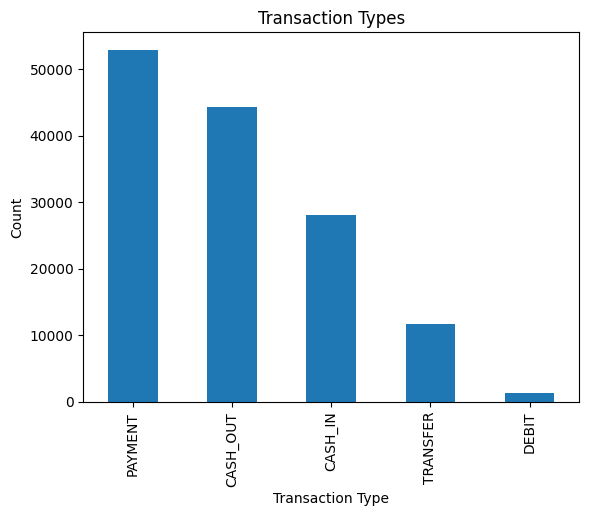

In [58]:
df['type'].value_counts().plot(kind='bar')

plt.title("Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

In [34]:
df['type'].value_counts(normalize=True) * 100

,proportion
type,
PAYMENT,38.276074
CASH_OUT,32.042139
CASH_IN,20.270789
TRANSFER,8.479890
DEBIT,0.931108


In [35]:
print("Total Transactions :", len(df))
print("Unique Customers :", df['nameOrig'].nunique())
print("Unique Recipients :", df['nameDest'].nunique())

Total Transactions : 138115
Unique Customers : 138114
Unique Recipients : 68438


In [36]:
df['Transaction_Category'] = df['type'].replace({
    'PAYMENT':'Merchant Payment',
    'TRANSFER':'Peer Transfer',
    'CASH_IN':'Wallet Load',
    'CASH_OUT':'Wallet Withdrawal',
    'DEBIT':'Card Payment'
})

df[['type','Transaction_Category']].head()

,type,Transaction_Category
0,PAYMENT,Merchant Payment
1,PAYMENT,Merchant Payment
2,TRANSFER,Peer Transfer
3,CASH_OUT,Wallet Withdrawal
4,PAYMENT,Merchant Payment


In [42]:
df['Amount_Segment'] = pd.cut(
    df['amount'],
    bins=[0,1000,10000,50000,200000,float('inf')],
    labels=['Low','Medium','High','Very High','Premium']
)

df['Amount_Segment'].value_counts()

,count
Amount_Segment,
Premium,38136
High,34107
Very High,33565
Medium,28672
Low,3635


In [43]:
df.groupby('Amount_Segment')['amount'].agg(
    ['count','sum','mean']
)

/tmp/ipykernel_4158/3761651414.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Amount_Segment')['amount'].agg(


,count,sum,mean
Amount_Segment,,,
Low,3635,1.839494e+06,506.050726
Medium,28672,1.492445e+08,5205.236623
High,34107,7.629600e+08,22369.601706
Very High,33565,4.043841e+09,120477.900954
Premium,38136,1.968562e+10,516195.125592


In [44]:
print("Total Transaction Value :", round(df['amount'].sum(),2))
print("Average Transaction Value :", round(df['amount'].mean(),2))
print("Maximum Transaction Value :", round(df['amount'].max(),2))

Total Transaction Value : 24643502099.35
Average Transaction Value : 178427.41
Maximum Transaction Value : 10000000.0


In [45]:
print("Fraud Transactions :", df['isFraud'].sum())

print("Fraud Rate (%) :",
      round((df['isFraud'].sum()/len(df))*100,4))

Fraud Transactions : 122.0
Fraud Rate (%) : 0.0883


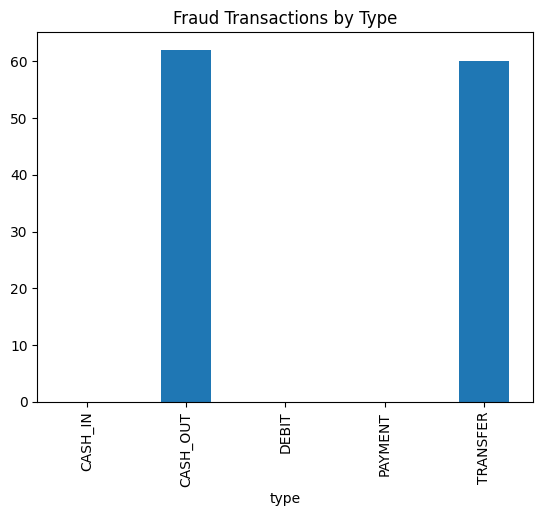

In [46]:
fraud_by_type = df.groupby('type')['isFraud'].sum()

fraud_by_type.plot(kind='bar')

plt.title("Fraud Transactions by Type")
plt.show()

In [47]:
total_transactions = len(df)

total_value = df['amount'].sum()

avg_transaction = df['amount'].mean()

unique_customers = df['nameOrig'].nunique()

fraud_transactions = df['isFraud'].sum()

fraud_rate = (fraud_transactions/total_transactions)*100

print("Total Transactions:", total_transactions)
print("Total Value:", round(total_value,2))
print("Average Transaction:", round(avg_transaction,2))
print("Unique Customers:", unique_customers)
print("Fraud Rate:", round(fraud_rate,4))

Total Transactions: 138115
Total Value: 24643502099.35
Average Transaction: 178427.41
Unique Customers: 138114
Fraud Rate: 0.0883


In [48]:
df.groupby('type')['amount'].sum().sort_values(ascending=False)

,amount
type,
TRANSFER,1.021965e+10
CASH_OUT,8.859086e+09
CASH_IN,4.954851e+09
PAYMENT,6.042051e+08
DEBIT,5.708982e+06


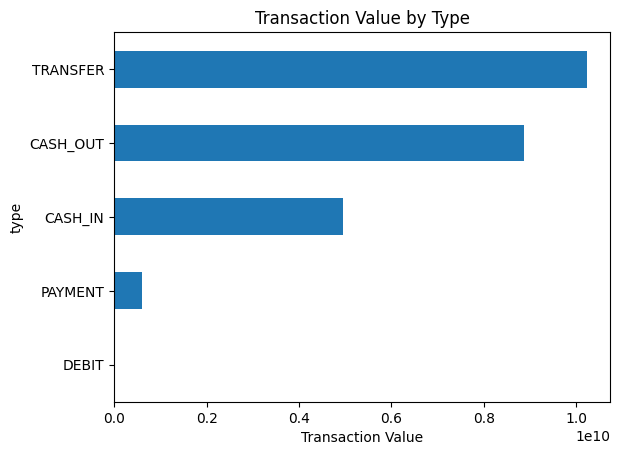

In [49]:
df.groupby('type')['amount'].sum().sort_values().plot(kind='barh')

plt.title("Transaction Value by Type")
plt.xlabel("Transaction Value")
plt.show()

In [50]:
top_customers = df.groupby('nameOrig')['amount'].sum()

top_customers.sort_values(ascending=False).head(10)

,amount
nameOrig,
C351297720,10000000.00
C7162498,10000000.00
C890128330,6419835.27
C2022065686,6072832.27
C293394374,5677662.29
C1588880909,5460002.91
C666654362,5460002.91
C574755786,5082871.40
C551242513,5077695.81


In [51]:
top_merchants = df.groupby('nameDest')['amount'].sum()

top_merchants.sort_values(ascending=False).head(10)

,amount
nameDest,
C97730845,36616292.11
C1590550415,35814539.06
C248609774,33931196.27
C665576141,31974362.30
C2083562754,29090633.57
C1360767589,28646767.65
C1883840933,28486311.92
C985934102,27993393.02
C1286084959,27218969.66


In [59]:
df['Payment_Method'] = df['type'].replace({
    'PAYMENT':'UPI',
    'TRANSFER':'Bank Transfer',
    'CASH_IN':'Wallet',
    'CASH_OUT':'Wallet',
    'DEBIT':'Debit Card'
})

df['Payment_Method'].value_counts()

,count
Payment_Method,
Wallet,72252
UPI,52865
Bank Transfer,11712
Debit Card,1286


In [60]:
df['Transaction_Status'] = np.where(
    df['isFraud']==1,
    'Failed',
    'Successful'
)

df['Transaction_Status'].value_counts()

,count
Transaction_Status,
Successful,137993
Failed,122


In [61]:
success_rate = (
    (df['Transaction_Status']=='Successful').sum()
    / len(df)
) * 100

print("Success Rate :", round(success_rate,2), "%")

Success Rate : 99.91 %


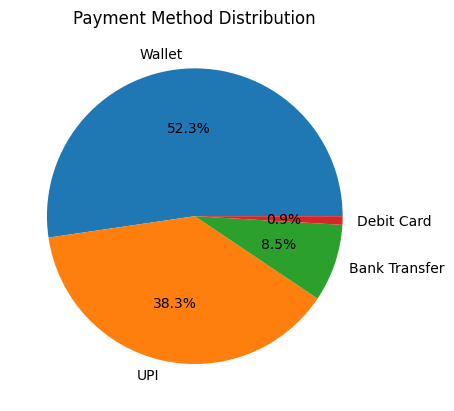

In [62]:
df['Payment_Method'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

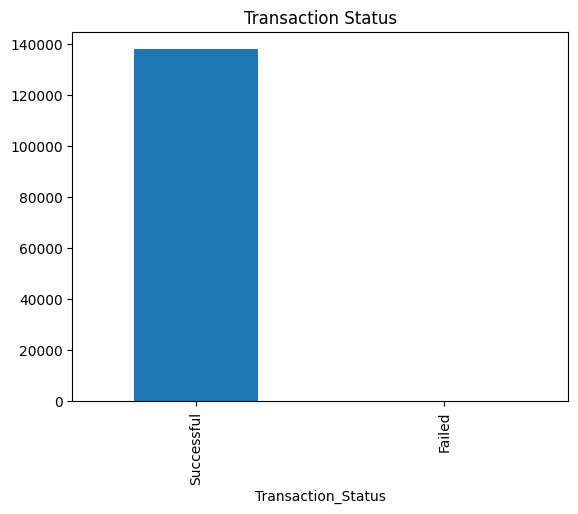

In [63]:
df['Transaction_Status'].value_counts().plot(
    kind='bar'
)

plt.title("Transaction Status")
plt.show()

In [64]:
final_df = df[[
    'type',
    'amount',
    'nameOrig',
    'nameDest',
    'isFraud',
    'Payment_Method',
    'Transaction_Status',
    'Transaction_Category',
    'Amount_Segment'
]]

In [65]:
final_df.head()

,type,amount,nameOrig,nameDest,isFraud,Payment_Method,Transaction_Status,Transaction_Category,Amount_Segment
0,PAYMENT,9839.64,C1231006815,M1979787155,0.0,UPI,Successful,Merchant Payment,Medium
1,PAYMENT,1864.28,C1666544295,M2044282225,0.0,UPI,Successful,Merchant Payment,Medium
2,TRANSFER,181.00,C1305486145,C553264065,1.0,Bank Transfer,Failed,Peer Transfer,Low
3,CASH_OUT,181.00,C840083671,C38997010,1.0,Wallet,Failed,Wallet Withdrawal,Low
4,PAYMENT,11668.14,C2048537720,M1230701703,0.0,UPI,Successful,Merchant Payment,High


In [66]:
final_df.shape

(138115, 9)

In [67]:
final_df.to_csv(
    "Digital_Payments_Final_Dataset.csv",
    index=False
)

print("Dataset Exported Successfully")

Dataset Exported Successfully


In [68]:
df['step'].value_counts().sort_index()

,count
step,
1,2708
2,1014
3,552
4,565
5,665
6,1660
7,6837
8,21097
9,37628


In [69]:
print("Minimum Step:", df['step'].min())
print("Maximum Step:", df['step'].max())
print("Unique Steps:", df['step'].nunique())

Minimum Step: 1
Maximum Step: 11
Unique Steps: 11


In [70]:
final_df.columns

Index(['type', 'amount', 'nameOrig', 'nameDest', 'isFraud', 'Payment_Method',
       'Transaction_Status', 'Transaction_Category', 'Amount_Segment'],
      dtype='object')

In [71]:
final_df = df[[
    'step',
    'type',
    'amount',
    'nameOrig',
    'nameDest',
    'isFraud',
    'Payment_Method',
    'Transaction_Status',
    'Transaction_Category',
    'Amount_Segment'
]]

In [75]:
final_df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'nameDest', 'isFraud',
       'Payment_Method', 'Transaction_Status', 'Transaction_Category',
       'Amount_Segment'],
      dtype='object')

In [76]:
final_df.to_csv(
    "Digital_Payments_final_Dataset.csv",
    index=False
)

print("Export Successful")

Export Successful


In [78]:
pd.read_csv("Digital_Payments_final_Dataset.csv").head()

,step,type,amount,nameOrig,nameDest,isFraud,Payment_Method,Transaction_Status,Transaction_Category,Amount_Segment
0,1,PAYMENT,9839.64,C1231006815,M1979787155,0.0,UPI,Successful,Merchant Payment,Medium
1,1,PAYMENT,1864.28,C1666544295,M2044282225,0.0,UPI,Successful,Merchant Payment,Medium
2,1,TRANSFER,181.00,C1305486145,C553264065,1.0,Bank Transfer,Failed,Peer Transfer,Low
3,1,CASH_OUT,181.00,C840083671,C38997010,1.0,Wallet,Failed,Wallet Withdrawal,Low
4,1,PAYMENT,11668.14,C2048537720,M1230701703,0.0,UPI,Successful,Merchant Payment,High


# Conclusion

This project successfully transformed raw digital payment transaction data into a business-ready analytical dataset suitable for FinTech intelligence reporting.

Key outcomes of the analysis include:

- Identification of transaction volume and value trends.
- Analysis of payment method distribution across transactions.
- Measurement of transaction success and fraud rates.
- Classification of transactions into meaningful business categories.
- Segmentation of transactions based on value ranges.
- Discovery of high-value customers and recipients.

The engineered dataset and generated insights provide a strong foundation for building interactive Power BI dashboards and supporting data-driven decision-making in digital payment ecosystems.

This project demonstrates practical skills in data cleaning, exploratory data analysis, feature engineering, business analytics, and FinTech reporting using Python, SQL, and Power BI.